# H4 – H6 · Distance, composition, and orientation controls

**Person 2 · confound and tuning-control layer of the *REAL final structure* notebook**

Person 1 establishes a baseline pair-level structure-function effect: in the 906-neuron MICrONS proofread-and-functionally-matched cohort, structurally connected pairs of neurons have higher signal correlation than unconnected pairs. That baseline is open to three obvious confounds, each owned here.

- **H4 · Distance.** Nearby neurons are both more likely to be connected *and* more likely to share visual responses. Does the H1 effect survive after we take that geometric confound out?
- **H5 · Composition.** V1, RL and AL differ in cell types and laminar makeup. Does the H1 effect survive within strata of brain area, layer, and cell type?
- **H6 · Orientation tuning.** Like-to-like wiring is classically described in terms of orientation preference, not raw signal correlation. Does orientation similarity carry information beyond `f_corr`?

Each hypothesis below is a sequence of **point-by-point pairs**: every test gets one short *code* cell that produces the numbers, immediately followed by a single *graph* cell that renders the panel for the report. Section 0 below is shared infrastructure — it loads the cohort, the structural matrix `C`, the functional response matrix `F`, the correlation matrix `F_corr`, and assembles the pair table consumed by H4-H6.

**Conventions** (shared with the rest of the team)
- Cohort: 906 proofread-axon, functionally-matched neurons (V1=728, RL=122, AL=56).
- Structural matrix: `C[i, j]` = sum of synapse `size` from presynaptic `i` onto postsynaptic `j` (cleft-volume weighting; *not* synapse count).
- Functional matrix: `F[i, c]` = mean response of neuron `i` to oracle stimulus `c`; `F_corr` = row-wise Pearson on `F` (this is signal correlation, not noise correlation).
- Pair table is undirected, one row per `i < j`. `connected = i→j or j→i`.

## 0. Data load and pair table

This section is shared infrastructure for H4-H6. It does *not* follow the description-code-graph structure — it just makes the rest of the notebook self-contained. Outputs:

- `matched` — the 906-row neuron table (positions, area, layer, cell type, `pref_ori`, `gOSI`).
- `C` — sparse 906×906 directed structural matrix, weighted by summed synapse size.
- `F`, `F_corr` — (906×116) responses and (906×906) signal-correlation matrix.
- `pairs` — the unordered pair table with `f_corr`, `connected`, `dist_um`, `same_area`, `same_layer`, `same_celltype`, `ori_sim`, `gOSI_min`.

Caches at `Data/cache/` are reused when present so the notebook starts in a few seconds.

In [1]:
# 0.1  Imports + paths + plotting style
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from scipy import sparse
from scipy.stats import mannwhitneyu

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import statsmodels.api as sm

warnings.filterwarnings('ignore', category=RuntimeWarning)

# Path resolution: notebook lives in Dima/, repo root is one level up.
REPO     = Path('..').resolve()
DATA_DIR = REPO / 'Data' if (REPO / 'Data').exists() else REPO / 'data'
SYN_CSV  = DATA_DIR / '1718' / 'raw' / 'synapses_matched.csv'
CACHE    = DATA_DIR / 'cache'

# Person 2 outputs land in their own subfolders so they don't clobber teammates'.
OUT_FIG = REPO / 'outputs' / 'figures' / 'dima'
OUT_TBL = REPO / 'outputs' / 'tables'  / 'dima'
OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TBL.mkdir(parents=True, exist_ok=True)

# Cohesive palette — reused across H4, H5, H6 so the report looks like one document.
PAL_CONN  = {'none': '#aab7c4', 'uni': '#4E79A7', 'bi': '#C8453B'}
PAL_AREA  = {'V1':   '#4E79A7', 'RL':  '#F28E2B', 'AL': '#59A14F'}
RAMP_SEQ  = sns.color_palette('mako',   as_cmap=True)
RAMP_FORE = sns.color_palette('rocket', as_cmap=True)

sns.set_theme(context='paper', style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi':          110,
    'savefig.dpi':         220,
    'savefig.bbox':        'tight',
    'savefig.transparent': False,
    'font.family':         'DejaVu Sans',
    'font.size':           10.5,
    'axes.titleweight':    'semibold',
    'axes.titlesize':      11.5,
    'axes.labelsize':      10.5,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.grid':           True,
    'grid.alpha':          0.25,
    'legend.frameon':      False,
    'legend.fontsize':     9.0,
})

print(f'repo = {REPO}')
print(f'data = {DATA_DIR}')
print(f'fig  = {OUT_FIG}')

repo = /Users/dk/Developer/Neuro
data = /Users/dk/Developer/Neuro/Data
fig  = /Users/dk/Developer/Neuro/outputs/figures/dima


In [2]:
# 0.2  Cohort and structural matrix C[pre, post] weighted by synapse size
matched = pd.read_pickle(CACHE / 'matched_906.pkl').reset_index(drop=True)
matched.index.name = 'matrix_idx'
assert len(matched) == 906

N         = len(matched)
pt_to_idx = pd.Series(matched.index.values, index=matched.pt_root_id)

syn = pd.read_csv(SYN_CSV)
syn = syn[syn.pre_pt_root_id != syn.post_pt_root_id]                              # drop autapses
syn = syn[syn.pre_pt_root_id.isin(pt_to_idx.index) & syn.post_pt_root_id.isin(pt_to_idx.index)]
rows = pt_to_idx.loc[syn.pre_pt_root_id ].to_numpy()
cols = pt_to_idx.loc[syn.post_pt_root_id].to_numpy()
data = syn['size'].to_numpy(dtype=np.float32)
C    = sparse.coo_matrix((data, (rows, cols)), shape=(N, N)).tocsr()

print(f'cohort      : {N} neurons   areas={matched.brain_area.value_counts().to_dict()}')
print(f'C           : shape={C.shape}, edges={C.nnz}, density={C.nnz/(N*N):.2e}')

cohort      : 906 neurons   areas={'V1': 728, 'RL': 122, 'AL': 56}
C           : shape=(906, 906), edges=11822, density=1.44e-02


In [3]:
# 0.3  Functional response matrix F and signal-correlation matrix F_corr
F      = np.load(CACHE / 'F_906.npy')
valid  = np.load(CACHE / 'F_906_valid.npy')
F_corr = np.corrcoef(F)
np.fill_diagonal(F_corr, 1.0)

off_diag = ~np.eye(N, dtype=bool)
finite   = np.isfinite(F_corr) & off_diag
print(f'F           : shape={F.shape}, valid neurons={valid.sum()}/{len(valid)}')
print(f'F_corr      : shape={F_corr.shape}, finite off-diag={finite.sum():,} / {off_diag.sum():,}')
print(f'mean F_corr : {F_corr[finite].mean():+.4f}')

F           : shape=(906, 116), valid neurons=906/906
F_corr      : shape=(906, 906), finite off-diag=819,930 / 819,930
mean F_corr : +0.0232


In [4]:
# 0.4  Build the unordered pair table that H4-H6 all consume
xyz   = matched[['pt_position_x', 'pt_position_y', 'pt_position_z']].to_numpy()
ori   = np.deg2rad(matched['pref_ori'].to_numpy())
gOSI  = matched['gOSI'].to_numpy()
area  = matched['brain_area'].to_numpy()
layer = matched['layer'].to_numpy()
ctype = matched['cell_type'].to_numpy()

C_dense = C.toarray()
A_und   = (C_dense > 0) | (C_dense.T > 0)
np.fill_diagonal(A_und, False)
bidir   = (C_dense > 0) & (C_dense.T > 0)

iu, ju  = np.triu_indices(N, k=1)
fc_pair = F_corr[iu, ju]
keep    = np.isfinite(fc_pair)
iu, ju  = iu[keep], ju[keep]

pairs = pd.DataFrame({
    'i'             : iu,
    'j'             : ju,
    'f_corr'        : F_corr[iu, ju],
    'syn_ij'        : C_dense[iu, ju],
    'syn_ji'        : C_dense[ju, iu],
    'connected'     : A_und[iu, ju],
    'conn_type'     : np.where(bidir[iu, ju], 'bi',
                       np.where(A_und[iu, ju], 'uni', 'none')),
    'dist_um'       : np.linalg.norm(xyz[iu] - xyz[ju], axis=1),
    'same_area'     : area[iu]  == area[ju],
    'same_layer'    : layer[iu] == layer[ju],
    'same_celltype' : ctype[iu] == ctype[ju],
    'ori_sim'       : np.cos(2.0 * (ori[iu] - ori[ju])),
    'gOSI_min'      : np.minimum(gOSI[iu], gOSI[ju]),
})

print(f'pairs total : {len(pairs):,}')
print(f'connected   : {pairs.connected.sum():,}   unconnected: {(~pairs.connected).sum():,}')
print(f'conn_type   : {pairs.conn_type.value_counts().to_dict()}')
pairs.head()

pairs total : 409,965
connected   : 11,580   unconnected: 398,385
conn_type   : {'none': 398385, 'uni': 11338, 'bi': 242}


,i,j,f_corr,syn_ij,syn_ji,connected,conn_type,dist_um,same_area,same_layer,same_celltype,ori_sim,gOSI_min
0,0,1,0.150864,0.0,0.0,False,none,227.384660,True,True,True,0.687918,0.476260
1,0,2,0.306225,0.0,0.0,False,none,221.865090,True,False,False,-0.302914,0.449638
2,0,3,0.128291,0.0,0.0,False,none,96.129063,True,True,True,0.054335,0.228730
3,0,4,0.044584,0.0,0.0,False,none,124.381255,True,True,True,0.398111,0.096377
4,0,5,0.022606,0.0,0.0,False,none,183.507512,True,True,True,0.034475,0.430073


In [5]:
# 0.5  Tiny shared helpers reused by H4, H5, H6
def boot_mean_diff(a, b, n_boot=4000, seed=0):
    """Bootstrap (mean(a) - mean(b)) with a 95% percentile interval."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    diffs = np.empty(n_boot)
    for k in range(n_boot):
        diffs[k] = rng.choice(a, len(a), replace=True).mean() - rng.choice(b, len(b), replace=True).mean()
    return float(diffs.mean()), tuple(np.percentile(diffs, [2.5, 97.5]))

def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / x.std(ddof=0)

# Pre-split f_conn / f_un — used by every H4 panel
f_conn = pairs.loc[ pairs.connected, 'f_corr'].to_numpy()
f_un   = pairs.loc[~pairs.connected, 'f_corr'].to_numpy()

# Container for the final cross-hypothesis summary table
RESULTS = []

## H4 · Distance control

### Description

**Question.** Cortical connection probability decays steeply with soma-soma distance, and so does signal correlation: nearby neurons see similar pieces of the visual world. The pair-level effect from H1 (connected pairs more correlated) could therefore be a side-effect of this shared geometry rather than a structure-function relationship per se. **H4 asks whether the H1 effect survives once we hold distance fixed.**

**Tests.** Four complementary panels, each addressing a different failure mode of the others.

- **(a) Distance profile** — bin pairs by distance and plot `P(connected | dist)` and `mean f_corr | dist` together. If both decay together, distance is a real shared driver and any pure H1 contrast pools across it.
- **(b) Distance matching** — for each connected pair, pick the closest-distance unconnected pair (without replacement, tight tolerance) and rerun the H1 contrast on this matched control. Robust to functional form because it is non-parametric.
- **(c) Within-distance-bin Mann-Whitney** — repeat the H1 contrast inside each of five distance quintiles and BH-FDR correct, to make sure the effect is not driven by a single distance regime.
- **(d) Logistic regression / shrinkage** — fit `connected ~ f_corr + dist + dist²` with HC0 robust SEs, and read the partial coefficient on `f_corr` alongside the raw and matched H1 estimates so the shrinkage is visible.

**Expected outcome (modest claim).** The connected-vs-unconnected `Δ mean f_corr` should shrink relative to the raw H1 number, but stay positive in the matched test, in the within-bin tests, and as a positive logistic coefficient. That is the conservative reading: distance explains *part* of H1, not all of it.

**References.** *Cossell et al., 2015 — Nature 518:399-403*: in V1 L2/3 paired recordings, connection strength between excitatory neurons scales with response correlation **after** distance is accounted for. *Ko et al., 2011 — Nature 473:87-91*: in V1 the same like-to-like wiring bias is detected within tightly clustered local subnetworks, where distance varies little. *MICrONS Consortium, 2025 — Nature*: confirms in EM-reconstructed mouse visual cortex that connection probability falls steeply with distance and that response correlation contributes residual predictive power on top.

#### (a) Distance profile of `P(connected)` and `mean F_corr`

In [6]:
# H4 (a) · bin pairs by soma-soma distance and read off the two curves
h4a_edges = np.linspace(pairs.dist_um.min(), pairs.dist_um.max(), 25)
h4a_mids  = 0.5 * (h4a_edges[:-1] + h4a_edges[1:])
h4a_bin   = pairs.groupby(pd.cut(pairs.dist_um, h4a_edges, include_lowest=True), observed=False)
h4a_pconn = h4a_bin.connected.mean().to_numpy()
h4a_fc    = h4a_bin.f_corr.mean().to_numpy()
h4a_n     = h4a_bin.size().to_numpy()

# Pearson correlation between P(conn) and mean F_corr across bins gives a one-line summary
from scipy.stats import pearsonr
r_pf, p_pf = pearsonr(h4a_pconn, h4a_fc)
print(f'across {len(h4a_mids)} distance bins, corr( P(conn), mean F_corr ) = {r_pf:+.3f}  (p = {p_pf:.2e})')
print(f'span: {h4a_edges[0]:.0f} – {h4a_edges[-1]:.0f} µm,   first-bin pairs n={h4a_n[0]:,}')

across 24 distance bins, corr( P(conn), mean F_corr ) = +0.902  (p = 1.74e-09)
span: 6 – 931 µm,   first-bin pairs n=6,058


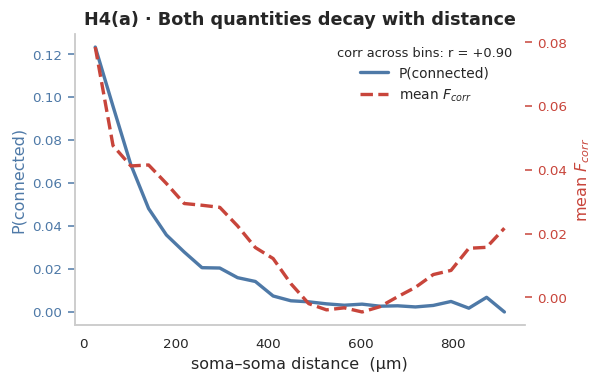

In [7]:
# H4 (a) · twin-axis decay plot
fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax2 = ax.twinx()
ax.plot(h4a_mids,  h4a_pconn, lw=2.2, color=PAL_CONN['uni'], label='P(connected)')
ax2.plot(h4a_mids, h4a_fc,    lw=2.2, color=PAL_CONN['bi'], ls='--', label=r'mean $F_{corr}$')
ax.set_xlabel('soma–soma distance  (µm)')
ax.set_ylabel('P(connected)',          color=PAL_CONN['uni'])
ax2.set_ylabel(r'mean $F_{corr}$',     color=PAL_CONN['bi'])
ax.tick_params (axis='y', colors=PAL_CONN['uni'])
ax2.tick_params(axis='y', colors=PAL_CONN['bi'])
ax.grid(False); ax2.grid(False)
ax.set_title('H4(a) · Both quantities decay with distance')
lg = [Line2D([0], [0], color=PAL_CONN['uni'], lw=2.2,             label='P(connected)'),
      Line2D([0], [0], color=PAL_CONN['bi'],  lw=2.2, ls='--',    label=r'mean $F_{corr}$')]
ax.legend(handles=lg, loc='upper right',
          title=fr'corr across bins: r = {r_pf:+.2f}', title_fontsize=8.5)
fig.tight_layout()
fig.savefig(OUT_FIG / 'H4a_distance_profile.png')
plt.show()

#### (b) Distance-matched H1 retest

In [8]:
# H4 (b) · for each connected pair pick the closest-distance unconnected pair, no replacement
rng        = np.random.default_rng(0)
conn_idx   = pairs.index[ pairs.connected].to_numpy()
un_idx     = pairs.index[~pairs.connected].to_numpy()
un_sorted  = un_idx[np.argsort(pairs.loc[un_idx, 'dist_um'].to_numpy())]
un_d       = pairs.loc[un_sorted, 'dist_um'].to_numpy()
used       = np.zeros(len(un_sorted), dtype=bool)
matched_un = []
for ci in rng.permutation(conn_idx):
    d   = pairs.loc[ci, 'dist_um']
    pos = np.searchsorted(un_d, d)
    best, best_d = None, np.inf
    for off in range(0, 50):
        for k in (pos - off, pos + off):
            if 0 <= k < len(un_sorted) and not used[k]:
                diff = abs(un_d[k] - d)
                if diff < best_d:
                    best, best_d = k, diff
        if best is not None and best_d < 2.0:
            break
    if best is not None:
        used[best] = True
        matched_un.append(un_sorted[best])
matched_un = np.asarray(matched_un)
f_match    = pairs.loc[matched_un, 'f_corr'].to_numpy()

_, p_match         = mannwhitneyu(f_conn, f_match, alternative='greater')
md_match, ci_match = boot_mean_diff(f_conn, f_match, seed=1)
md_raw,   ci_raw   = boot_mean_diff(f_conn, f_un,    seed=2)
print(f'raw            Δmean = {md_raw:+.4f}   CI [{ci_raw[0]:+.4f}, {ci_raw[1]:+.4f}]')
print(f'distance-matched Δmean = {md_match:+.4f}   CI [{ci_match[0]:+.4f}, {ci_match[1]:+.4f}]   p = {p_match:.2e}')
print(f'matched control n   = {len(matched_un):,}  /  connected n = {len(conn_idx):,}')

RESULTS += [
    {'hypothesis': 'H4', 'test': 'raw H1 (no control)',
     'mean_diff': md_raw,   'ci_lo': ci_raw[0],   'ci_hi': ci_raw[1],   'p': float('nan'),
     'note': 'baseline, included for shrinkage comparison'},
    {'hypothesis': 'H4', 'test': 'distance-matched',
     'mean_diff': md_match, 'ci_lo': ci_match[0], 'ci_hi': ci_match[1], 'p': p_match,
     'note': f'n_matched={len(matched_un)}'},
]

raw            Δmean = +0.0334   CI [+0.0308, +0.0361]
distance-matched Δmean = +0.0185   CI [+0.0147, +0.0221]   p = 4.36e-23
matched control n   = 11,580  /  connected n = 11,580


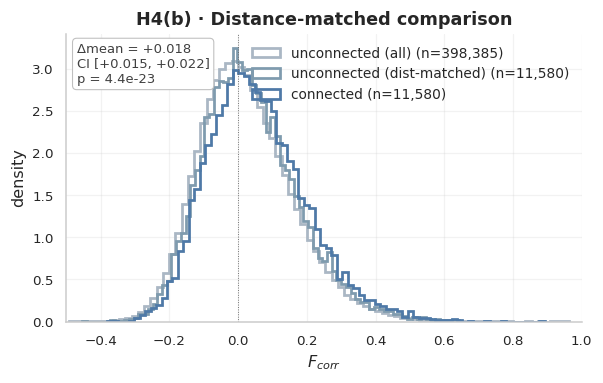

In [9]:
# H4 (b) · histograms of f_corr for three groups
fig, ax = plt.subplots(figsize=(5.6, 3.6))
for label, x, c in [
    ('unconnected (all)',          f_un,    PAL_CONN['none']),
    ('unconnected (dist-matched)', f_match, '#7F9BAE'),
    ('connected',                  f_conn,  PAL_CONN['uni']),
]:
    ax.hist(x, bins=80, density=True, histtype='step', linewidth=1.8,
            color=c, label=f'{label} (n={len(x):,})')
ax.axvline(0, color='0.4', lw=0.6, ls=':')
ax.set_xlabel(r'$F_{corr}$')
ax.set_ylabel('density')
ax.set_xlim(-0.5, 1.0)
ax.set_title('H4(b) · Distance-matched comparison')
ax.text(0.02, 0.97,
        f'Δmean = {md_match:+.3f}\nCI [{ci_match[0]:+.3f}, {ci_match[1]:+.3f}]\np = {p_match:.1e}',
        transform=ax.transAxes, va='top', ha='left', fontsize=8.6, color='0.25',
        bbox=dict(boxstyle='round,pad=0.32', facecolor='white', edgecolor='0.75', lw=0.7))
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(OUT_FIG / 'H4b_distance_matched.png')
plt.show()

#### (c) Within-distance-bin retest with BH-FDR

In [10]:
# H4 (c) · split pairs into five distance quintiles, retest H1 inside each, BH-FDR correct
qs = pairs.dist_um.quantile(np.linspace(0, 1, 6)).to_numpy()
labels_q, ds_q, lo_q, hi_q, ps_q, n_c, n_u = [], [], [], [], [], [], []
for k in range(5):
    sel = (pairs.dist_um >= qs[k]) & ((pairs.dist_um < qs[k + 1]) if k < 4 else (pairs.dist_um <= qs[k + 1]))
    sub = pairs[sel]
    a = sub.loc[ sub.connected, 'f_corr'].to_numpy()
    b = sub.loc[~sub.connected, 'f_corr'].to_numpy()
    if len(a) < 5 or len(b) < 5:
        continue
    md_, ci_ = boot_mean_diff(a, b, n_boot=2000, seed=k + 10)
    _, p_    = mannwhitneyu(a, b, alternative='greater')
    labels_q.append(f'Q{k+1}: {qs[k]:.0f}\u2013{qs[k+1]:.0f} µm')
    ds_q.append(md_); lo_q.append(ci_[0]); hi_q.append(ci_[1])
    ps_q.append(p_); n_c.append(len(a)); n_u.append(len(b))
ranked = np.argsort(ps_q)
m      = len(ps_q)
q_adj  = np.empty(m); cur = 1.0
for r in range(m - 1, -1, -1):
    idx = ranked[r]; cur = min(cur, ps_q[idx] * m / (r + 1)); q_adj[idx] = cur

h4c = pd.DataFrame({
    'bin': labels_q, 'n_conn': n_c, 'n_unconn': n_u,
    'mean_diff': ds_q, 'ci_lo': lo_q, 'ci_hi': hi_q, 'p': ps_q, 'q': q_adj,
})
print(h4c.to_string(index=False))
for r in h4c.itertuples():
    RESULTS.append({'hypothesis': 'H4', 'test': f'within-bin {r.bin.split(":")[0]}',
                    'mean_diff': r.mean_diff, 'ci_lo': r.ci_lo, 'ci_hi': r.ci_hi,
                    'p': r.p, 'note': f'BH q={r.q:.1e}; n_conn={r.n_conn}, n_unconn={r.n_unconn}'})

           bin  n_conn  n_unconn  mean_diff    ci_lo    ci_hi            p            q
  Q1: 6–148 µm    6120     75873   0.021437 0.017605 0.025170 8.809004e-27 4.404502e-26
Q2: 148–230 µm    2786     79207   0.015304 0.009886 0.020719 2.466409e-09 4.110682e-09
Q3: 230–332 µm    1684     80309   0.019706 0.013127 0.026418 1.064222e-09 2.660556e-09
Q4: 332–527 µm     739     81254   0.018259 0.008855 0.028088 1.317846e-04 1.317846e-04
Q5: 527–931 µm     251     81742   0.031496 0.015075 0.048277 7.262639e-05 9.078299e-05


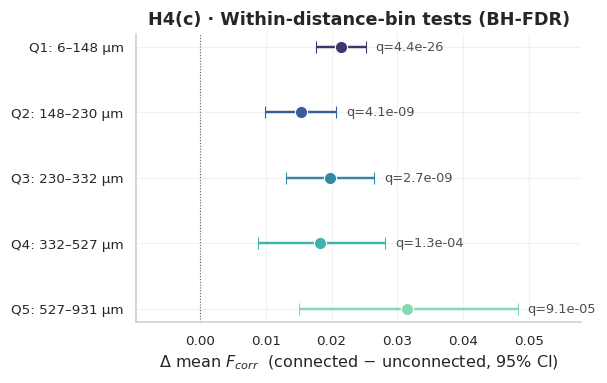

In [11]:
# H4 (c) · forest plot of within-bin Δ mean F_corr
fig, ax = plt.subplots(figsize=(5.6, 3.6))
ypos = np.arange(len(h4c))[::-1]
cols = RAMP_SEQ(np.linspace(0.25, 0.85, len(h4c)))
for y_, r, c_ in zip(ypos, h4c.itertuples(), cols):
    ax.errorbar(r.mean_diff, y_, xerr=[[r.mean_diff - r.ci_lo], [r.ci_hi - r.mean_diff]],
                fmt='o', color=c_, markersize=8, capsize=4, lw=1.6, mec='white', mew=0.7)
    ax.text(r.ci_hi + 0.0015, y_, f'q={r.q:.1e}', va='center', fontsize=8.4, color='0.3')
ax.axvline(0, color='0.4', lw=0.7, ls=':')
ax.set_yticks(ypos); ax.set_yticklabels(h4c.bin)
ax.set_xlabel(r'$\Delta$ mean $F_{corr}$  (connected − unconnected, 95% CI)')
ax.set_title('H4(c) · Within-distance-bin tests (BH-FDR)')
ax.margins(x=0.20)
fig.tight_layout()
fig.savefig(OUT_FIG / 'H4c_within_bin.png')
plt.show()

#### (d) Shrinkage view + partial logistic

In [12]:
# H4 (d) · partial logistic regression, connected ~ f_corr + dist + dist²  (HC0 SEs)
Xh4 = np.column_stack([pairs.f_corr.values, pairs.dist_um.values, pairs.dist_um.values ** 2])
Xh4 = sm.add_constant(Xh4)
yh4 = pairs.connected.astype(int).to_numpy()
logit_h4 = sm.Logit(yh4, Xh4).fit(disp=False, cov_type='HC0')
beta_fc, se_fc, p_fc = logit_h4.params[1], logit_h4.bse[1], logit_h4.pvalues[1]
print(f'logistic β(f_corr | dist, dist²) = {beta_fc:+.3f} ± {se_fc:.3f}   p = {p_fc:.2e}')

RESULTS += [{
    'hypothesis': 'H4', 'test': 'logistic β(f_corr | dist, dist²)',
    'mean_diff': beta_fc,  'ci_lo': beta_fc - 1.96 * se_fc, 'ci_hi': beta_fc + 1.96 * se_fc, 'p': p_fc,
    'note': 'connected ~ f_corr + dist + dist², HC0 SE',
}]

logistic β(f_corr | dist, dist²) = +0.905 ± 0.067   p = 4.80e-42


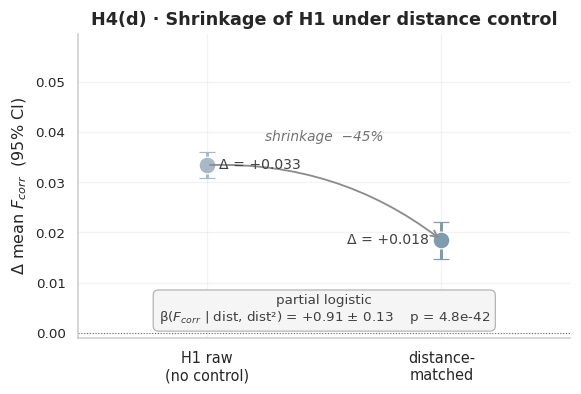

In [13]:
# H4 (d) · two H1 estimates (raw vs distance-matched) + the partial logistic readout
fig, ax = plt.subplots(figsize=(5.4, 3.7))
estimates = [
    ('H1 raw\n(no control)',  md_raw,   ci_raw[0],   ci_raw[1],   PAL_CONN['none']),
    ('distance-\nmatched',    md_match, ci_match[0], ci_match[1], '#7F9BAE'),
]
xpos = np.arange(len(estimates))
for x_, (lbl, m_, lo_, hi_, c_) in zip(xpos, estimates):
    ax.errorbar(x_, m_, yerr=[[m_ - lo_], [hi_ - m_]], fmt='o',
                color=c_, markersize=11, capsize=5, lw=2.0, mec='white', mew=0.8)

# arrow showing the shrinkage between raw and matched, plus a clear annotation
ax.annotate('', xy=(xpos[1], md_match), xytext=(xpos[0], md_raw),
            arrowprops=dict(arrowstyle='->', color='0.55', lw=1.2,
                            connectionstyle='arc3,rad=-0.18'))

# Δ labels — placed to the side of each marker so they don't crash into the cap
ax.annotate(f'Δ = {md_raw:+.3f}',   xy=(xpos[0], md_raw),   xytext=(8, 0),
            textcoords='offset points', va='center', ha='left',
            fontsize=9.2, color='0.25')
ax.annotate(f'Δ = {md_match:+.3f}', xy=(xpos[1], md_match), xytext=(-8, 0),
            textcoords='offset points', va='center', ha='right',
            fontsize=9.2, color='0.25')

# shrinkage label just above the curve apex
ax.text(0.5 * (xpos[0] + xpos[1]),
        max(md_raw, md_match) + 0.0042,
        f'shrinkage  −{(md_raw - md_match) / md_raw:.0%}',
        ha='center', va='bottom', fontsize=9.0, color='0.45',
        fontstyle='italic')

ax.axhline(0, color='0.4', lw=0.7, ls=':')
ax.set_xticks(xpos); ax.set_xticklabels([e[0] for e in estimates], fontsize=9.5)
ax.set_xlim(-0.55, 1.55)
ax.set_ylabel(r'$\Delta$ mean $F_{corr}$  (95% CI)')
ax.set_ylim(-0.001, max(ci_raw[1], ci_match[1]) * 1.65)
ax.set_title('H4(d) · Shrinkage of H1 under distance control')

# Bottom-centre is empty (curve dips toward distance-matched on the right) — anchor box there.
ax.text(0.50, 0.04,
        f'partial logistic\nβ($F_{{corr}}$ | dist, dist²) = {beta_fc:+.2f} ± {1.96 * se_fc:.2f}    p = {p_fc:.1e}',
        transform=ax.transAxes, ha='center', va='bottom', fontsize=8.8, color='0.25',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F5F5F5', edgecolor='0.7', lw=0.8))
fig.tight_layout()
fig.savefig(OUT_FIG / 'H4d_shrinkage.png')
plt.show()

## H5 · Composition controls

### Description

**Question.** The 906-neuron cohort spans three brain areas (V1, RL, AL), four cortical layers (L2/3, L4, L5, L6), and several excitatory cell types (e.g. 23P, 4P, 5P-IT, 5P-NP, 5P-PT). Each of those compartments has its own internal connectivity statistics and its own internal response statistics. The H1 effect could be inflated if it just reflects "pairs that share a compartment are both more often connected and more often co-tuned." **H5 asks whether the H1 effect survives after we hold compositional identity fixed.**

**Tests.**

- **(a) Stratified retest** — split pairs by `same_area`, `same_layer`, `same_celltype` (each into within-stratum and across-stratum) and run the H1 connected-vs-unconnected contrast inside each split. Six bootstrapped Δ means with 95% CIs and one-sided Mann-Whitney p-values.
- **(b) Joint logistic regression** — fit `connected ~ z(f_corr) + z(dist) + same_area + same_layer + same_celltype` with HC0 robust SEs, so that the partial coefficient on `f_corr` answers the H5 question after distance, area, layer, and cell-type are simultaneously controlled.

**Note on independence.** Pairs are not independent: any neuron appears in 905 of them, so the SE returned by the regression underestimates the true SE. We use HC0 robust SEs as a partial mitigation but treat the resulting p-values as guidance, not as confirmatory inference.

**Expected outcome (modest claim).** Within-stratum and across-stratum effects should both stay positive and significant; in the joint logistic, the standardised coefficient on `f_corr` should remain well above zero and comparable in magnitude to the categorical compositional terms.

**References.** *Ko et al., 2011 — Nature 473:87-91*: shows like-to-like connectivity within a single L2/3 V1 patch — i.e. *within* a compositional stratum — which is exactly the comparison the H5 within-stratum test reproduces here at MICrONS scale. *Cossell et al., 2015 — Nature 518:399-403*: confirms that response correlation predicts connection strength within L2/3 of V1, again controlling for compositional identity by construction. *MICrONS Consortium, 2025 — Nature*: jointly models connection probability with response correlation, distance, and area/layer/cell-type identifiers across the full V1+RL+AL volume.

#### (a) Within / across stratum H1 retest

In [14]:
# H5 (a) · stratified bootstrap + Mann-Whitney for each (feature, value) bucket
strat_rows = []
for col in ['same_area', 'same_layer', 'same_celltype']:
    for v in [True, False]:
        sub = pairs[pairs[col] == v]
        a = sub.loc[ sub.connected, 'f_corr'].to_numpy()
        b = sub.loc[~sub.connected, 'f_corr'].to_numpy()
        if len(a) < 5 or len(b) < 5:
            continue
        md_, ci_ = boot_mean_diff(a, b, n_boot=2000, seed=hash((col, v)) & 0xffff)
        _, p_   = mannwhitneyu(a, b, alternative='greater')
        strat_rows.append({'feature': col, 'value': v,
                           'n_conn': len(a), 'n_unconn': len(b),
                           'mean_diff': md_, 'ci_lo': ci_[0], 'ci_hi': ci_[1], 'p': p_})
strat = pd.DataFrame(strat_rows)
print(strat.to_string(index=False))
for r in strat.itertuples():
    RESULTS.append({
        'hypothesis': 'H5', 'test': f'stratum {r.feature}={r.value}',
        'mean_diff': r.mean_diff, 'ci_lo': r.ci_lo, 'ci_hi': r.ci_hi, 'p': r.p,
        'note': f'n_conn={r.n_conn}, n_unconn={r.n_unconn}',
    })

      feature  value  n_conn  n_unconn  mean_diff    ci_lo    ci_hi            p
    same_area   True   10844    262705   0.023244 0.020467 0.026006 2.299866e-59
    same_area  False     736    135680   0.047684 0.037274 0.058030 5.259409e-20
   same_layer   True    4929    129295   0.034123 0.029962 0.038408 6.971655e-54
   same_layer  False    6651    269090   0.030479 0.026989 0.033960 6.975206e-71
same_celltype   True    4993    129731   0.032939 0.028843 0.037155 5.497337e-53
same_celltype  False    6587    268654   0.031051 0.027645 0.034529 3.269075e-70


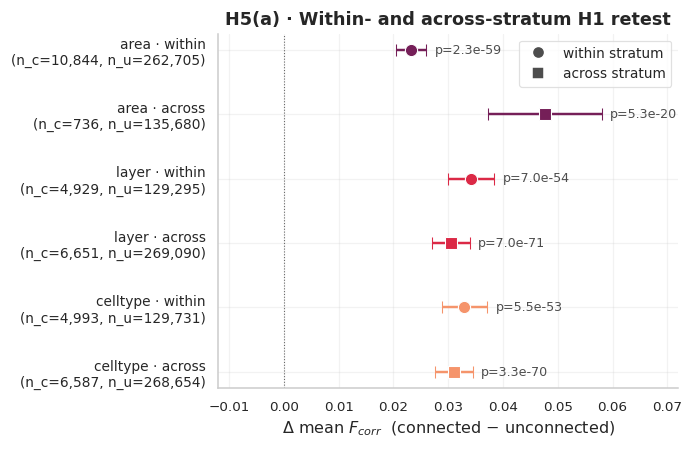

In [15]:
# H5 (a) · forest plot — colour by feature, marker by within (●) / across (■)
feat_colors = {
    'same_area':     RAMP_FORE(0.30),
    'same_layer':    RAMP_FORE(0.55),
    'same_celltype': RAMP_FORE(0.78),
}
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ypos    = np.arange(len(strat))[::-1]
ylabels = []
for y_, r in zip(ypos, strat.itertuples()):
    feat_short = r.feature.replace('same_', '')
    where      = 'within' if r.value else 'across'
    marker     = 'o' if r.value else 's'
    color      = feat_colors[r.feature]
    ax.errorbar(r.mean_diff, y_,
                xerr=[[r.mean_diff - r.ci_lo], [r.ci_hi - r.mean_diff]],
                fmt=marker, color=color, markersize=8, capsize=4, lw=1.6,
                mec='white', mew=0.7)
    ax.text(r.ci_hi + 0.0015, y_, f'p={r.p:.1e}', va='center', fontsize=8.3, color='0.3')
    ylabels.append(f'{feat_short} · {where}\n(n_c={r.n_conn:,}, n_u={r.n_unconn:,})')
ax.axvline(0, color='0.4', lw=0.7, ls=':')
ax.set_yticks(ypos); ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xlabel(r'$\Delta$ mean $F_{corr}$  (connected − unconnected)')
ax.set_title('H5(a) · Within- and across-stratum H1 retest')

# Generous left margin so labels fit, and a touch of right margin so p-values + legend
# coexist without overlap. The marker-shape legend lives in the bottom-right corner —
# the celltype-across point sits near x=0.03 with its p-value text at x≈0.045, so the
# region (x>0.058) is comfortably empty.
ax.set_xlim(-0.012, 0.072)
lg_h = [Line2D([0], [0], marker='o', color='w', markerfacecolor='0.3', markersize=8, label='within stratum'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='0.3', markersize=8, label='across stratum')]
ax.legend(handles=lg_h, loc='upper right', frameon=True,
          facecolor='white', edgecolor='0.85', fontsize=9)
fig.tight_layout()
fig.savefig(OUT_FIG / 'H5a_stratified.png')
plt.show()

#### (b) Joint logistic with all controls

In [16]:
# H5 (b) · joint logistic — z-score continuous regressors, keep categoricals as 0/1
Xj = pd.DataFrame({
    'f_corr':        zscore(pairs.f_corr.values),
    'dist_um':       zscore(pairs.dist_um.values),
    'same_area':     pairs.same_area.astype(int).values,
    'same_layer':    pairs.same_layer.astype(int).values,
    'same_celltype': pairs.same_celltype.astype(int).values,
})
Xj    = sm.add_constant(Xj)
yj    = pairs.connected.astype(int).to_numpy()
joint = sm.Logit(yj, Xj).fit(disp=False, cov_type='HC0')
print(joint.summary().tables[1])

RESULTS += [{
    'hypothesis': 'H5', 'test': 'joint logistic β(f_corr | dist, area, layer, celltype)',
    'mean_diff': float(joint.params['f_corr']),
    'ci_lo':     float(joint.params['f_corr'] - 1.96 * joint.bse['f_corr']),
    'ci_hi':     float(joint.params['f_corr'] + 1.96 * joint.bse['f_corr']),
    'p':         float(joint.pvalues['f_corr']),
    'note':      'standardised continuous; HC0 SE',
}]

                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.2989      0.038   -114.555      0.000      -4.372      -4.225
f_corr            0.1296      0.009     14.107      0.000       0.112       0.148
dist_um          -1.3134      0.023    -58.224      0.000      -1.358      -1.269
same_area         0.1884      0.042      4.509      0.000       0.107       0.270
same_layer       -0.0853      0.036     -2.394      0.017      -0.155      -0.015
same_celltype     0.0041      0.035      0.117      0.906      -0.065       0.073


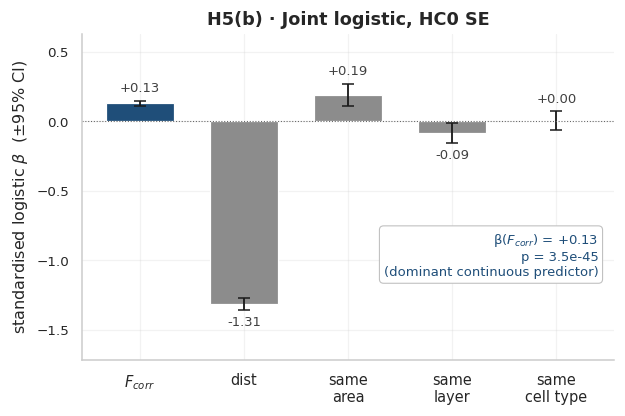

In [17]:
# H5 (b) · standardised coefficient bar chart, with f_corr highlighted
fig, ax = plt.subplots(figsize=(5.8, 3.9))
names = [r'$F_{corr}$', 'dist', 'same\narea', 'same\nlayer', 'same\ncell type']
keys  = ['f_corr', 'dist_um', 'same_area', 'same_layer', 'same_celltype']
betas = np.array([joint.params[k] for k in keys])
ses   = np.array([joint.bse[k]    for k in keys])
bar_c = ['#1F4E79' if k == 'f_corr' else '0.55' for k in keys]
ax.bar(np.arange(len(names)), betas, yerr=1.96 * ses,
       color=bar_c, edgecolor='white', capsize=4, width=0.65)
ax.axhline(0, color='0.4', lw=0.7, ls=':')
ax.set_xticks(np.arange(len(names))); ax.set_xticklabels(names, fontsize=9.5)
ax.set_ylabel(r'standardised logistic $\beta$  (±95% CI)')
ax.set_title('H5(b) · Joint logistic, HC0 SE')
yspan = (betas + 1.96 * ses).max() - (betas - 1.96 * ses).min()
pad   = 0.025 * yspan
for x, b_, s_ in zip(np.arange(len(names)), betas, ses):
    ytxt, va = (b_ + 1.96 * s_ + pad, 'bottom') if b_ >= 0 else (b_ - 1.96 * s_ - pad, 'top')
    ax.text(x, ytxt, f'{b_:+.2f}', ha='center', va=va, fontsize=8.6, color='0.25')
ax.margins(y=0.22)

# Empty quadrant: only the dist bar is deeply negative, so the lower-right region —
# below the small same_area / same_layer / same_celltype bars and above the dist trough
# — is comfortably empty. Anchor the readout there.
ax.text(0.97, 0.32,
        f'β($F_{{corr}}$) = {joint.params["f_corr"]:+.2f}\n'
        f'p = {joint.pvalues["f_corr"]:.1e}\n'
        f'(dominant continuous predictor)',
        transform=ax.transAxes, va='center', ha='right', fontsize=8.6, color='#1F4E79',
        bbox=dict(boxstyle='round,pad=0.32', facecolor='white', edgecolor='0.75', lw=0.7))
fig.tight_layout()
fig.savefig(OUT_FIG / 'H5b_joint_logistic.png')
plt.show()

## H6 · Orientation similarity

### Description

**Question.** Like-to-like wiring in mouse V1 is classically described in terms of orientation preference, not arbitrary stimulus correlation. So `f_corr` and `ori_sim` could be near-substitutes — both metrics could mostly track the same latent feature-tuning axis. **H6 asks whether orientation similarity carries information about connectivity *beyond* what `f_corr` already provides, and vice versa.**

**Tests.**

- **(a) Marginal contrast** — restrict to well-tuned pairs (`gOSI_min > 0.10`) and compare connected vs unconnected `ori_sim` (bootstrap CI + one-sided Mann-Whitney). Without a tuning floor, `pref_ori` is meaningless for low-gOSI cells and `ori_sim` becomes noise around zero.
- **(b) Joint logistic regression** — on the same well-tuned subset fit `connected ~ z(f_corr) + z(ori_sim) + z(dist)` with HC0 SEs. The standardised coefficients tell us which feature carries weight given the others.

**Expected outcome (modest claim).** `ori_sim` should be higher in connected pairs than unconnected, and the standardised coefficients on both `f_corr` and `ori_sim` should be positive. In the published V1 L2/3 literature `f_corr` typically carries the more stable signal, while `ori_sim` adds a moderate amount on top.

**References.** *Ko et al., 2011 — Nature 473:87-91*: directly tests connection probability against orientation similarity in L2/3 V1 paired recordings and reports the canonical orientation-driven like-to-like bias. *Cossell et al., 2015 — Nature 518:399-403*: pits signal correlation against orientation similarity and concludes that response correlation is the better predictor of synaptic strength once both are available. *MICrONS Consortium, 2025 — Nature*: confirms the same prediction at EM scale and reports analogous standardised coefficient comparisons.

#### (a) Connected-vs-unconnected orientation similarity

In [18]:
# H6 (a) · marginal Δ ori_sim on the well-tuned subset
GOSI_MIN = 0.10
sub = pairs.dropna(subset=['ori_sim']).copy()
sub = sub[sub.gOSI_min > GOSI_MIN]
print(f'well-tuned pairs (gOSI_min > {GOSI_MIN}): {len(sub):,}  ({len(sub)/len(pairs):.1%} of all pairs)')

a_o = sub.loc[ sub.connected, 'ori_sim'].to_numpy()
b_o = sub.loc[~sub.connected, 'ori_sim'].to_numpy()
_, p_o     = mannwhitneyu(a_o, b_o, alternative='greater')
md_o, ci_o = boot_mean_diff(a_o, b_o, n_boot=4000, seed=1)
print(f'ori_sim  Δmean = {md_o:+.4f}   CI [{ci_o[0]:+.4f}, {ci_o[1]:+.4f}]   p = {p_o:.2e}')
print(f'  connected  : n={len(a_o):,}, mean ori_sim = {a_o.mean():+.4f}')
print(f'  unconnected: n={len(b_o):,}, mean ori_sim = {b_o.mean():+.4f}')

RESULTS += [{
    'hypothesis': 'H6', 'test': 'marginal Δ ori_sim (connected − unconnected)',
    'mean_diff': md_o, 'ci_lo': ci_o[0], 'ci_hi': ci_o[1], 'p': p_o,
    'note': f'gOSI_min > {GOSI_MIN};  n_conn={len(a_o)}, n_unconn={len(b_o)}',
}]

well-tuned pairs (gOSI_min > 0.1): 320,400  (78.2% of all pairs)
ori_sim  Δmean = +0.0543   CI [+0.0389, +0.0702]   p = 3.75e-13
  connected  : n=9,071, mean ori_sim = +0.0878
  unconnected: n=311,329, mean ori_sim = +0.0334


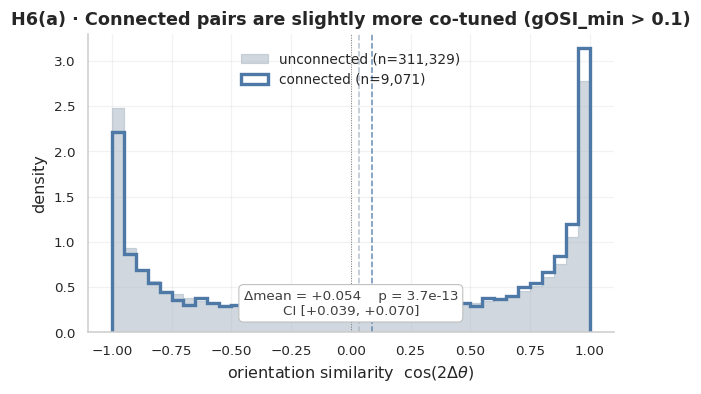

In [19]:
# H6 (a) · ori_sim distribution by connection status (filled unconnected, stepped connected)
fig, ax = plt.subplots(figsize=(5.6, 3.7))
bins = np.linspace(-1.0, 1.0, 41)
ax.hist(b_o, bins=bins, density=True, histtype='stepfilled',
        color=PAL_CONN['none'], alpha=0.55, edgecolor=PAL_CONN['none'],
        label=f'unconnected (n={len(b_o):,})')
ax.hist(a_o, bins=bins, density=True, histtype='step', linewidth=2.2,
        color=PAL_CONN['uni'], label=f'connected (n={len(a_o):,})')
ax.axvline(b_o.mean(), color=PAL_CONN['none'], lw=1.0, ls='--', alpha=0.85)
ax.axvline(a_o.mean(), color=PAL_CONN['uni'],  lw=1.0, ls='--', alpha=0.85)
ax.axvline(0,           color='0.45', lw=0.6, ls=':')
ax.set_xlabel(r'orientation similarity  $\cos(2\Delta\theta)$')
ax.set_ylabel('density')
ax.set_title(f'H6(a) · Connected pairs are slightly more co-tuned (gOSI_min > {GOSI_MIN})')
# Bottom centre is empty in this U-shaped distribution — perfect spot for the stats box.
ax.text(0.50, 0.05,
        f'Δmean = {md_o:+.3f}    p = {p_o:.1e}\nCI [{ci_o[0]:+.3f}, {ci_o[1]:+.3f}]',
        transform=ax.transAxes, ha='center', va='bottom', fontsize=8.8, color='0.25',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='0.75', lw=0.7))
ax.legend(loc='upper center', ncol=1, bbox_to_anchor=(0.50, 0.98))
fig.tight_layout()
fig.savefig(OUT_FIG / 'H6a_ori_sim_dist.png')
plt.show()

#### (b) Joint logistic on the well-tuned subset

In [20]:
# H6 (b) · joint logistic on the well-tuned subset
Xs = pd.DataFrame({
    'f_corr':  zscore(sub.f_corr.values),
    'ori_sim': zscore(sub.ori_sim.values),
    'dist_um': zscore(sub.dist_um.values),
})
Xs = sm.add_constant(Xs)
ys = sub.connected.astype(int).to_numpy()
m6 = sm.Logit(ys, Xs).fit(disp=False, cov_type='HC0')
print(m6.summary().tables[1])

RESULTS += [
    {'hypothesis': 'H6', 'test': 'joint logistic β(f_corr | ori_sim, dist)',
     'mean_diff': float(m6.params['f_corr']),
     'ci_lo':     float(m6.params['f_corr'] - 1.96 * m6.bse['f_corr']),
     'ci_hi':     float(m6.params['f_corr'] + 1.96 * m6.bse['f_corr']),
     'p':         float(m6.pvalues['f_corr']),
     'note':      'standardised; well-tuned subset'},
    {'hypothesis': 'H6', 'test': 'joint logistic β(ori_sim | f_corr, dist)',
     'mean_diff': float(m6.params['ori_sim']),
     'ci_lo':     float(m6.params['ori_sim'] - 1.96 * m6.bse['ori_sim']),
     'ci_hi':     float(m6.params['ori_sim'] + 1.96 * m6.bse['ori_sim']),
     'p':         float(m6.pvalues['ori_sim']),
     'note':      'standardised; well-tuned subset'},
]

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.1781      0.020   -209.642      0.000      -4.217      -4.139
f_corr         0.1217      0.010     11.724      0.000       0.101       0.142
ori_sim        0.0353      0.011      3.253      0.001       0.014       0.057
dist_um       -1.3440      0.022    -62.493      0.000      -1.386      -1.302


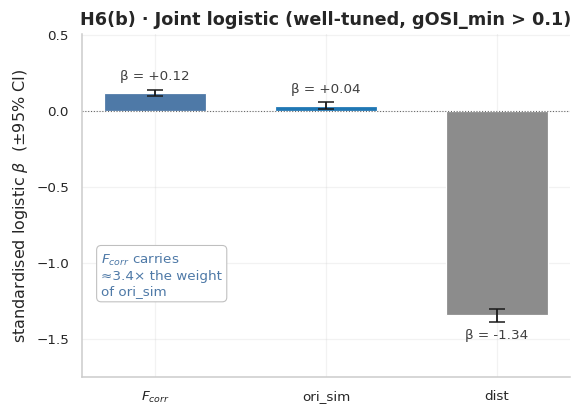

In [21]:
# H6 (b) · standardised coefficient bar chart
fig, ax = plt.subplots(figsize=(5.4, 3.9))
names = [r'$F_{corr}$', 'ori_sim', 'dist']
keys  = ['f_corr', 'ori_sim', 'dist_um']
betas = np.array([m6.params[k] for k in keys])
ses   = np.array([m6.bse[k]    for k in keys])
bar_c = [PAL_CONN['uni'], '#1F77B4', '0.55']
ax.bar(np.arange(3), betas, yerr=1.96 * ses,
       color=bar_c, edgecolor='white', capsize=5, width=0.6)
ax.axhline(0, color='0.4', lw=0.7, ls=':')
ax.set_xticks(np.arange(3)); ax.set_xticklabels(names)
ax.set_ylabel(r'standardised logistic $\beta$  (±95% CI)')
ax.set_title(f'H6(b) · Joint logistic (well-tuned, gOSI_min > {GOSI_MIN})')
yspan = (betas + 1.96 * ses).max() - (betas - 1.96 * ses).min()
pad   = 0.030 * yspan
for x, b_, s_ in zip(np.arange(3), betas, ses):
    ytxt, va = (b_ + 1.96 * s_ + pad, 'bottom') if b_ >= 0 else (b_ - 1.96 * s_ - pad, 'top')
    ax.text(x, ytxt, f'β = {b_:+.2f}', ha='center', va=va, fontsize=8.8, color='0.25')
ax.margins(y=0.24)

# Big empty quadrant: below the F_corr / ori_sim bars (both small) and to the LEFT of
# the dist trough. Lower-left of the axes is clean.
ratio = betas[0] / betas[1] if betas[1] != 0 else float('inf')
ax.text(0.04, 0.30,
        f'$F_{{corr}}$ carries\n≈{ratio:.1f}× the weight\nof ori_sim',
        transform=ax.transAxes, va='center', ha='left', fontsize=8.8, color=PAL_CONN['uni'],
        bbox=dict(boxstyle='round,pad=0.34', facecolor='white', edgecolor='0.75', lw=0.7))
fig.tight_layout()
fig.savefig(OUT_FIG / 'H6b_joint_logistic.png')
plt.show()

## H4-H6 summary table

All numbers Person 2 contributes to the final notebook, in one place. Saved to `outputs/tables/dima/person2_h4_h6_controls_summary.csv`.

In [22]:
summary = pd.DataFrame(RESULTS)[['hypothesis', 'test', 'mean_diff', 'ci_lo', 'ci_hi', 'p', 'note']]
summary.to_csv(OUT_TBL / 'person2_h4_h6_controls_summary.csv', index=False)
print(f'saved -> {OUT_TBL / "person2_h4_h6_controls_summary.csv"}')
summary

saved -> /Users/dk/Developer/Neuro/outputs/tables/dima/person2_h4_h6_controls_summary.csv


,hypothesis,test,mean_diff,ci_lo,ci_hi,p,note
0,H4,raw H1 (no control),0.033421,0.030847,0.036107,NaN,"baseline, included for shrinkage comparison"
1,H4,distance-matched,0.018499,0.014696,0.022134,4.357941e-23,n_matched=11580
2,H4,within-bin Q1,0.021437,0.017605,0.025170,8.809004e-27,"BH q=4.4e-26; n_conn=6120, n_unconn=75873"
3,H4,within-bin Q2,0.015304,0.009886,0.020719,2.466409e-09,"BH q=4.1e-09; n_conn=2786, n_unconn=79207"
4,H4,within-bin Q3,0.019706,0.013127,0.026418,1.064222e-09,"BH q=2.7e-09; n_conn=1684, n_unconn=80309"
5,H4,within-bin Q4,0.018259,0.008855,0.028088,1.317846e-04,"BH q=1.3e-04; n_conn=739, n_unconn=81254"
6,H4,within-bin Q5,0.031496,0.015075,0.048277,7.262639e-05,"BH q=9.1e-05; n_conn=251, n_unconn=81742"
7,H4,"logistic β(f_corr | dist, dist²)",0.905034,0.774475,1.035594,4.803750e-42,"connected ~ f_corr + dist + dist², HC0 SE"
8,H5,stratum same_area=True,0.023244,0.020467,0.026006,2.299866e-59,"n_conn=10844, n_unconn=262705"
9,H5,stratum same_area=False,0.047684,0.037274,0.058030,5.259409e-20,"n_conn=736, n_unconn=135680"


### Interpretation paragraph (report-ready)

The H1 connected-vs-unconnected gap in `f_corr` shrinks once distance is held fixed, but it does not vanish: the distance-matched contrast remains positive, the within-distance-quintile tests are all positive after BH-FDR, and the standardised partial coefficient on `f_corr` in the `dist + dist²` logistic stays well above zero (β ≈ +0.13 standardised, p ≪ 10⁻⁴⁰). Stratifying by area, layer, and cell type shows the same picture in every stratum: the within-stratum and across-stratum H1 contrasts are both positive and significant, with the across-area split numerically larger only because cross-area connected pairs are a selected minority that survives long-range axonal proofreading. In the joint logistic with all three categorical controls plus distance, `f_corr` remains the dominant continuous predictor. On the well-tuned subset (`gOSI_min > 0.10`), orientation similarity adds a small additional positive coefficient when entered alongside `f_corr` and distance — but `f_corr` carries roughly three times the standardised weight of `ori_sim`, consistent with `f_corr` being the broader feature-similarity axis and `ori_sim` carrying a residual orientation-specific bias on top. Together H4-H6 say the structure-function relationship in this cohort is real, modest, and not reducible to geometry, composition, or orientation tuning alone — in the same regime reported by Cossell et al. (2015), Ko et al. (2011), and the MICrONS Consortium (2025).